# Laboratorio 4: Simulación de eventos discretos
## 5.2 Red de colas

**Curso:** Simulación Computacional · Universidad de los Llanos · **Estudiante:** Duván Felipe Baquero · **Código:** 160005002

Este cuaderno parte de la copia del ejemplo del profesor *Red de Colas.ipynb*, que implementa la red de colas
de la sección 5.5.2 de [Rios08]: un centro de revisión técnico-mecánica (ITV) con tres nodos.

- **N1**, ventanilla de documentación y pago. Servicio $N(\mu_1, \sigma_1)$ truncada en 0.
- **N2**, nave auxiliar para pruebas adicionales. Solo pasa el 40 % de los vehículos (los de más de 10 años).
  Servicio exponencial de media $\mu_2$.
- **N3**, nave principal, por donde pasan todos. Servicio $N(\mu_{31}, \sigma_{31})$ si hay menos de 5
  vehículos ($n_3 < 5$) y $N(\mu_{32}, \sigma_{32})$ si hay 5 o más, porque los operarios se apuran.

Todas las colas son FIFO y de capacidad infinita. Se aceptan llegadas hasta $T$ y después se sigue atendiendo
hasta que sale el último vehículo.

```
 llegadas ──► [N1] ──0,4──► [N2] ──┐
                 │                 ▼
                 └──────0,6─────► [N3] ──► salida
```

**Convención de los parámetros.** En el ejemplo los tiempos entre llegadas se generan con
`np.random.exponential(L)`, y NumPy interpreta ese argumento como la **media** (escala), no como la tasa. Lo
mismo pasa con `np.random.exponential(mu2)`. Se respeta esa convención: con $\lambda = 2$ el tiempo medio entre
llegadas es 2. Si se leyera $\lambda$ como tasa, llegaría un vehículo cada 0,5 unidades de tiempo a una
ventanilla que tarda 2,1 en promedio, y la red colapsaría por completo en el nodo 1.

**Cambios respecto al ejemplo.** Los parámetros se toman del escenario activo, el bucle principal quedó dentro
de `simular()` para repetirlo 20 veces y se fija una semilla de NumPy por escenario para que el cuaderno sea
reproducible. Además se corrigieron dos errores del ejemplo que afectan las medidas:

1. **Número promedio de clientes por nodo.** En el ejemplo cada rutina acumulaba el área $n_j(t_{suc} - t)$
   solo del nodo que ella misma modifica, pero el reloj `t` avanza con los sucesos de todos los nodos. Cuando
   entre dos sucesos del nodo 2 ocurría, por ejemplo, una salida del nodo 3, ese tramo de tiempo se perdía
   para el nodo 2. Así, `n_med_n1`, `n_med_n2` y `n_med_n3` salían subestimados. Ahora la función
   `acumular_areas()` suma el área de los tres nodos en cada suceso, antes de mover el reloj.
2. **Registro de la trayectoria.** El ejemplo guardaba $(t, n_1, n_2, n_3)$ una sola vez por vuelta del
   bucle, aunque en una vuelta se pueden procesar hasta cuatro sucesos. Se perdían estados intermedios, y con
   ellos posibles máximos. Ahora `registrar()` guarda el estado después de cada suceso.

Las rutinas de sucesos, el orden de las llamadas al generador y las fórmulas son las del ejemplo, así que con
la misma semilla se simula exactamente la misma historia; solo cambia cómo se mide.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)

def guardar(nombre):
    if os.path.isdir("figuras"):
        plt.savefig(f"figuras/{nombre}.pdf", bbox_inches="tight")

### Rutinas de sucesos (tomadas del ejemplo)

Hay cuatro sucesos: la llegada de un vehículo (`tLL1`) y la salida de cada uno de los tres nodos (`tS1`,
`tS2`, `tS3`). Al comenzar cada rutina, `acumular_areas()` suma $n_j \times (t_{suc} - t)$ para los tres
nodos: es el área bajo la curva del número de clientes de cada nodo, que dividida por el tiempo total da el
número promedio de clientes.

In [2]:
def acumular_areas(tsuc):
    # CORRECCIÓN: el área de los TRES nodos se acumula en cada suceso, antes de mover el reloj
    global n_med_n1, n_med_n2, n_med_n3
    n_med_n1 = n_med_n1 + n1*(tsuc - t)
    n_med_n2 = n_med_n2 + n2*(tsuc - t)
    n_med_n3 = n_med_n3 + n3*(tsuc - t)

def Llegada_cliente(tsuc):
    global t, n_med_n1, n1, NLL1, LL1, TSuc, mu1, sigma1, LLt
    acumular_areas(tsuc)
    n1 = n1 + 1

    LLt.append(tsuc)

    NLL1 = NLL1 + 1
    LL1.append(tsuc)
    t = tsuc

    Y = np.random.exponential(L)

    if (t+Y) < T:
        TSuc['tLL1'] = t + Y
    if n1 == 1:
        Y = np.random.normal(mu1, sigma1)
        if Y < 0:
            Y = 0
        TSuc['tS1'] = t + Y

def Servicio_nodo1(tsuc):
    global t, n1, n2, n3, n_med_n1, n_med_n2, n_med_n3, NS1, S1, NLL2, NLL3, LL2, LL3, TSuc, mu31, sigma31, mu2, mu1, sigma1
    acumular_areas(tsuc)
    n1 = n1 - 1

    NS1 = NS1 + 1
    S1.append(tsuc)
    U = np.random.uniform(0,1)
    if U <= 0.4:
        n2 = n2 + 1

        NLL2 = NLL2 + 1
        LL2.append(tsuc)
        if n2 == 1:
            Z = np.random.exponential(mu2)
            TSuc['tS2'] = tsuc + Z
    else:
        n3 = n3 + 1

        NLL3 = NLL3 + 1
        LL3.append(tsuc)
        if n3 == 1:
            W = np.random.normal(mu31, sigma31)
            if W < 0:
                W = 0
            TSuc['tS3'] = tsuc + W
    t = tsuc
    if n1 > 0:
        S = np.random.normal(mu1, sigma1)
        if S < 0:
            S = 0
        TSuc['tS1'] = tsuc + S

def Servicio_nodo2(tsuc):
    global t, n2, n3, n_med_n2, n_med_n3, NS2, NLL3, LL3, S2, TSuc, mu31, sigma31, mu2
    acumular_areas(tsuc)
    n2 = n2 - 1

    NS2 = NS2 + 1
    S2.append(tsuc)
    if n2 > 0:
        Y = np.random.exponential(mu2)
        TSuc['tS2'] = tsuc + Y
    n3 = n3 + 1

    NLL3 = NLL3 + 1
    LL3.append(tsuc)
    if n3 == 1:
        W = np.random.normal(mu31, sigma31)
        if W < 0:
            W = 0
        TSuc['tS3'] = tsuc + W
    t = tsuc

def Servicio_nodo3(tsuc):
    global t, n3, n_med_n3, NS3, S3, TSuc, mu31, sigma31, mu32, sigma32, St
    acumular_areas(tsuc)
    n3 = n3 - 1

    St.append(tsuc)

    NS3 = NS3 + 1
    S3.append(tsuc)
    if n3 > 0:
        if n3 < 5:
            R = np.random.normal(mu31, sigma31)
        else:
            R = np.random.normal(mu32, sigma32)
        if R < 0:
            R = 0
        TSuc['tS3'] = tsuc + R
    t = tsuc

### Programa principal

Es el bucle del ejemplo: en cada vuelta se busca el suceso con el menor instante en `TSuc` y se ejecuta su
rutina. Al final se calculan las medidas. El tiempo medio en el sistema se calcula como en el ejemplo (y en el
libro): tiempo medio en N1, más 0,4 veces el tiempo medio en N2, más el tiempo medio en N3, porque solo el 40 %
de los vehículos pasa por N2.

In [3]:
M = 999999.0

def registrar(tsuc):
    # CORRECCIÓN: se guarda el estado después de CADA suceso (el ejemplo lo hacía una vez por vuelta del bucle)
    at.append(tsuc)
    an1.append(n1)
    an2.append(n2)
    an3.append(n3)
    an.append(n1+n2+n3)

def fijar_escenario(p):
    global L, mu1, sigma1, mu2, mu31, sigma31, mu32, sigma32, T
    L, mu1, sigma1, mu2 = p["L"], p["mu1"], p["sigma1"], p["mu2"]
    mu31, sigma31, mu32, sigma32 = p["mu31"], p["sigma31"], p["mu32"], p["sigma32"]
    T = p["T"]

def simular():
    global at, LLt, St, an1, an2, an3, an, t, tsuc, Tp
    global NLL1, NLL2, NLL3, NS1, NS2, NS3, n1, n2, n3, n_med_n1, n_med_n2, n_med_n3
    global TSuc, LL1, LL2, LL3, S1, S2, S3
    at, LLt, St, an1, an2, an3, an = [0.0], [], [], [0], [0], [0], [0]
    t = tsuc = Tp = 0
    NLL1 = NLL2 = NLL3 = NS1 = NS2 = NS3 = n1 = n2 = n3 = 0
    n_med_n1 = n_med_n2 = n_med_n3 = 0
    TSuc = {"tLL1": M, "tS1": M, "tS2": M, "tS3": M}
    LL1, LL2, LL3, S1, S2, S3 = [], [], [], [], [], []

    X = np.random.exponential(L)

    if X > T:
        Tp = t_med_sistema = 0.0
        n_med_n1 = n_med_n2 = n_med_n3 = 0
        an = [0]
    else:
        Llegada_cliente(X)
        while (min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) != M):
            if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tLL1']:
                tsuc = TSuc['tLL1']
                TSuc['tLL1'] = M
                Llegada_cliente(tsuc)
                registrar(tsuc)
            if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS1']:
                tsuc = TSuc['tS1']
                TSuc['tS1'] = M
                Servicio_nodo1(tsuc)
                registrar(tsuc)
            if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS2']:
                tsuc = TSuc['tS2']
                TSuc['tS2'] = M
                Servicio_nodo2(tsuc)
                registrar(tsuc)
            if min([TSuc['tLL1'],TSuc['tS1'],TSuc['tS2'],TSuc['tS3']]) == TSuc['tS3']:
                tsuc = TSuc['tS3']
                TSuc['tS3'] = M
                Servicio_nodo3(tsuc)
                registrar(tsuc)

        Tp = max(0, t-T)
        acumulo1 = acumulo2 = acumulo3 = 0.0
        for ind in range(NLL1):
            acumulo1 = acumulo1 + S1[ind] - LL1[ind]
        for ind in range(NLL2):
            acumulo2 = acumulo2 + S2[ind] - LL2[ind]
        for ind in range(NLL3):
            acumulo3 = acumulo3 + S3[ind] - LL3[ind]

        t_med_sistema = (acumulo1/NLL1) + (0.4*acumulo2/NLL2) + (acumulo3/NLL3)

        n_med_n1 = n_med_n1 / t
        n_med_n2 = n_med_n2 / t
        n_med_n3 = n_med_n3 / t

    return {"t_med_sistema": t_med_sistema,
            "n_med_n1": n_med_n1, "n_med_n2": n_med_n2, "n_med_n3": n_med_n3,
            "Tp (desde T hasta la última salida)": Tp,
            "Máximo de clientes en el sistema": max(an),
            "n1 (pasaron por N1)": NS1, "n2 (pasaron por N2)": NS2, "n3 (pasaron por N3)": NS3,
            "Total de clientes del sistema": NLL3}

PREGUNTAS = ["¿Cuál es el tiempo medio de los clientes en el sistema (t_med_sistema)?",
             "¿Cuál es el número promedio de clientes en el nodo 1 (n_med_n1)?",
             "¿Cuál es el número promedio de clientes en el nodo 2 (n_med_n2)?",
             "¿Cuál es el número promedio de clientes en el nodo 3 (n_med_n3)?",
             "¿Cuál es el tiempo transcurrido desde T hasta que el último cliente abandona el sistema?",
             "¿Cuál es el número máximo de clientes en el sistema?",
             "¿Cuál es el total de clientes que pasaron por el nodo 1 (n1)?",
             "¿Cuál es el total de clientes que pasaron por el nodo 2 (n2)?",
             "¿Cuál es el total de clientes que pasaron por el nodo 3 (n3)?",
             "¿Cuál es el total de clientes que pasaron por el sistema?"]

def responder(res):
    filas = [(p, round(v, 4) if isinstance(v, float) else v) for p, v in zip(PREGUNTAS, res.values())]
    return pd.DataFrame(filas, columns=["Pregunta", "Respuesta"]).set_index("Pregunta")

def graficar(titulo, nombre):
    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True,
                            gridspec_kw={"height_ratios": [0.6, 1.4, 1.4, 1.4, 1.8]})
    axs[0].plot(LLt, np.ones(len(LLt)), "r.", ms=4, label="llegadas")
    axs[0].plot(St, np.zeros(len(St)), "b.", ms=4, label="salidas")
    axs[0].set_yticks([0, 1], ["salidas", "llegadas"]); axs[0].set_ylim(-0.6, 1.6)
    for ax, serie, etiqueta in zip(axs[1:], [an1, an2, an3, an], ["n1 (nodo 1)", "n2 (nodo 2)", "n3 (nodo 3)", "n (sistema)"]):
        ax.step(at, serie, where="post", lw=1.1, color="#1f4e79")
        ax.axvline(T, color="gray", ls="--", lw=1)
        ax.set_ylabel(etiqueta)
    axs[-1].set_xlabel("tiempo (t)")
    axs[0].set_title(titulo)
    for ax in axs:
        ax.set_xlim(0, max(at))
    plt.tight_layout(); guardar(nombre); plt.show()

def repetir(p, repeticiones, semilla):
    fijar_escenario(p)
    np.random.seed(semilla)
    filas = [simular() for _ in range(repeticiones)]
    return pd.DataFrame(filas, index=pd.RangeIndex(1, repeticiones + 1, name="Repetición"))

def resumen_ic(df, confianza=0.95):
    n = len(df)
    media, desv = df.mean(), df.std(ddof=1)
    tcrit = stats.t.ppf(1 - (1 - confianza) / 2, n - 1)
    semi = tcrit * desv / math.sqrt(n)
    return pd.DataFrame({"Media": media, "Desv. estándar": desv,
                         "IC 95 % inferior": media - semi, "IC 95 % superior": media + semi,
                         "Semiancho": semi, "Semiancho / media (%)": 100 * semi / media})

---
### Escenario A

$T = 300$; tiempo entre llegadas exponencial con $\lambda = 2$; N1: $N(2{,}1;\ 0{,}5)$; N2: exponencial con
$\mu_2 = 2{,}4$; N3: $N(4{,}1;\ 2{,}5)$ si $n_3 < 5$ y $N(3{,}0;\ 2{,}0)$ si $n_3 \ge 5$.

**Primera repetición**, con la que se responden las preguntas:

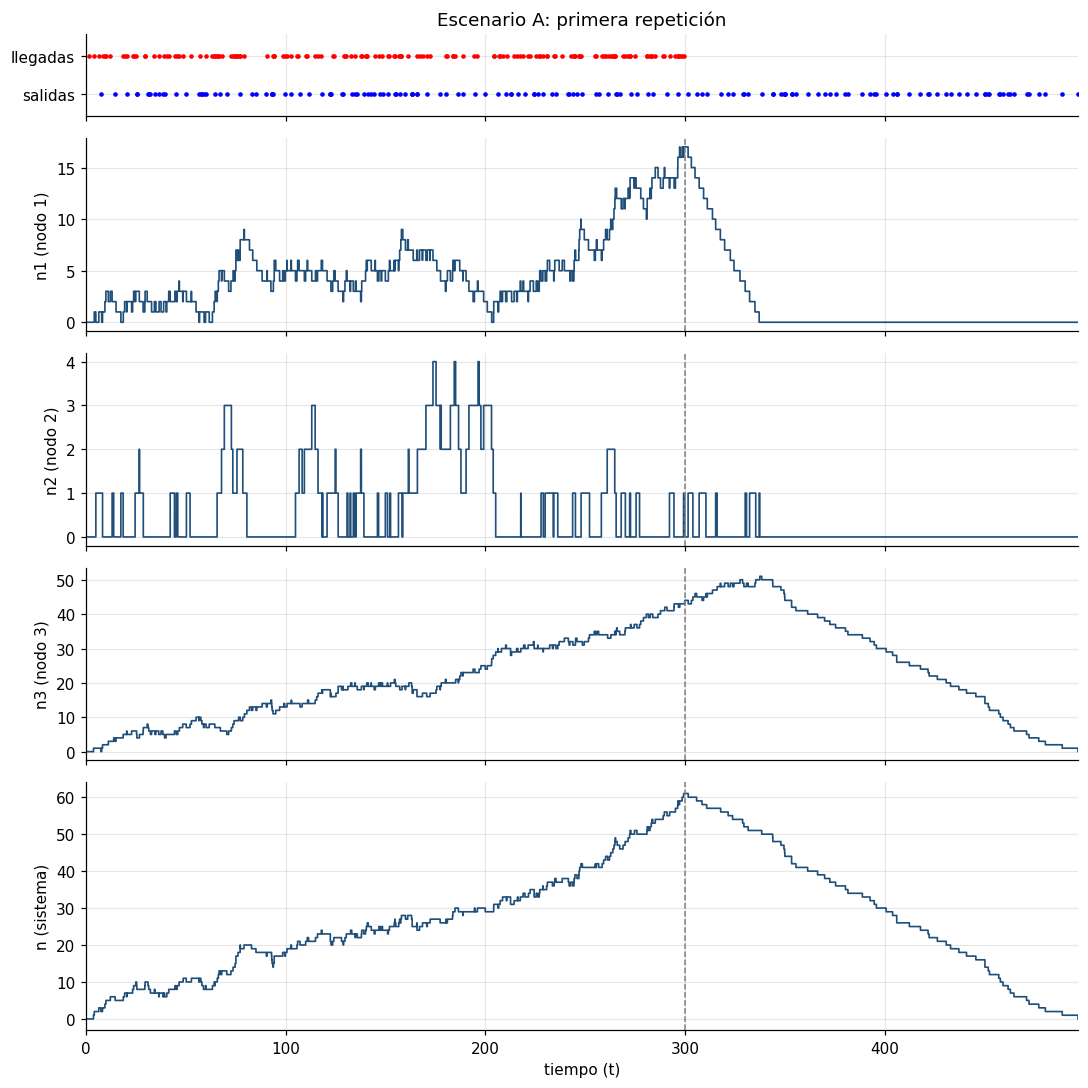

,Respuesta
Pregunta,
¿Cuál es el tiempo medio de los clientes en el sistema (t_med_sistema)?,87.2638
¿Cuál es el número promedio de clientes en el nodo 1 (n_med_n1)?,3.7653
¿Cuál es el número promedio de clientes en el nodo 2 (n_med_n2)?,0.4598
¿Cuál es el número promedio de clientes en el nodo 3 (n_med_n3)?,23.1522
¿Cuál es el tiempo transcurrido desde T hasta que el último cliente abandona el sistema?,196.7626
¿Cuál es el número máximo de clientes en el sistema?,61.0000
¿Cuál es el total de clientes que pasaron por el nodo 1 (n1)?,156.0000
¿Cuál es el total de clientes que pasaron por el nodo 2 (n2)?,59.0000
¿Cuál es el total de clientes que pasaron por el nodo 3 (n3)?,156.0000


In [4]:
esc_A = {"T": 300.0, "L": 2.0, "mu1": 2.1, "sigma1": 0.5, "mu2": 2.4,
         "mu31": 4.1, "sigma31": 2.5, "mu32": 3.0, "sigma32": 2.0}

fijar_escenario(esc_A)
np.random.seed(2024)
res_A1 = simular()
graficar("Escenario A: primera repetición", "52_escA")
responder(res_A1)

**Verificación de la corrección.** Si la cola es FIFO y todos los clientes salen antes de terminar la
simulación, el área bajo la curva de $n_j(t)$ es exactamente la suma de los tiempos que pasó cada cliente en el
nodo, $\sum_i (S_j(i) - LL_j(i))$ (ley de Little aplicada a la muestra). Los dos cálculos deben coincidir. La
última columna es lo que daba el código original del ejemplo con esta misma corrida:

In [5]:
verif = pd.DataFrame({
    "n_med (acumulando áreas)": [n_med_n1, n_med_n2, n_med_n3],
    "Σ(S - LL) / t": [(sum(S1) - sum(LL1)) / t, (sum(S2) - sum(LL2)) / t, (sum(S3) - sum(LL3)) / t],
    "Cálculo del ejemplo original": [2.6697, 0.1936, 16.9373]}, index=["Nodo 1", "Nodo 2", "Nodo 3"])
verif

,n_med (acumulando áreas),Σ(S - LL) / t,Cálculo del ejemplo original
Nodo 1,3.7653,3.7653,2.6697
Nodo 2,0.4598,0.4598,0.1936
Nodo 3,23.1522,23.1522,16.9373



**Respuestas del escenario A (primera repetición):** el tiempo medio en el sistema fue 87,26; en promedio hubo
3,77 vehículos en N1, 0,46 en N2 y 23,15 en N3; el último vehículo salió 196,76 unidades de tiempo después de
$T$; el máximo en el sistema fue 61; pasaron 156 vehículos por N1, 59 por N2 y 156 por N3, que son los 156 que
pasaron por el sistema.

En la gráfica se ve dónde está el problema. N1 se congestiona a ratos pero se recupera, N2 pasa el 57 % del tiempo vacío
(y menos del 10 % con tres o más vehículos) y N3 no para de crecer hasta $T$. Con los parámetros de A, a N3 llegan unos 0,48 vehículos por
unidad de tiempo (lo que deja salir N1), y aun trabajando rápido ($\mu_{32} = 3$) solo atiende 0,33. Después de
$T$ hace falta casi 200 unidades de tiempo para vaciar la nave principal. Nótese también que la corrección del
promedio de clientes por nodo no es un detalle: en N3 el código original daba 16,94 y el valor correcto es
23,15.


**Veinte repeticiones del escenario A** (la primera es la de arriba, porque se usa la misma semilla):

In [6]:
df_A = repetir(esc_A, 20, 2024)
df_A

,t_med_sistema,n_med_n1,n_med_n2,n_med_n3,Tp (desde T hasta la última salida),Máximo de clientes en el sistema,n1 (pasaron por N1),n2 (pasaron por N2),n3 (pasaron por N3),Total de clientes del sistema
Repetición,,,,,,,,,,
1,87.2638,3.7653,0.4598,23.1522,196.7626,61,156,59,156,156
2,68.5751,1.6838,0.5074,19.8869,115.9141,39,134,52,134,134
3,68.5451,3.6328,0.4412,17.2376,158.9840,45,143,52,143,143
4,79.2205,3.3736,0.3526,18.9387,165.2366,52,133,56,133,133
5,122.3899,15.2846,0.5315,23.0547,229.3583,73,168,71,168,168
6,132.8121,8.7211,0.4569,30.3184,278.5821,83,172,71,172,172
7,42.6699,1.4872,0.5729,11.0785,108.1447,31,125,57,125,125
8,61.5826,3.4205,0.4495,16.0447,124.0184,45,137,57,137,137
9,95.1662,7.0478,0.3396,22.0650,174.4983,51,147,54,147,147


In [7]:
tabla_A = resumen_ic(df_A)
tabla_A

,Media,Desv. estándar,IC 95 % inferior,IC 95 % superior,Semiancho,Semiancho / media (%)
t_med_sistema,93.1046,22.9643,82.3569,103.8522,10.7476,11.5436
n_med_n1,6.3089,3.4278,4.7046,7.9132,1.6043,25.4287
n_med_n2,0.4162,0.1035,0.3677,0.4646,0.0484,11.6391
n_med_n3,22.4450,4.6100,20.2874,24.6025,2.1576,9.6127
Tp (desde T hasta la última salida),184.4745,43.3683,164.1775,204.7715,20.2970,11.0026
Máximo de clientes en el sistema,59.6500,13.1360,53.5021,65.7979,6.1479,10.3065
n1 (pasaron por N1),152.0000,12.5153,146.1427,157.8573,5.8573,3.8535
n2 (pasaron por N2),58.5000,6.9016,55.2700,61.7300,3.2300,5.5214
n3 (pasaron por N3),152.0000,12.5153,146.1427,157.8573,5.8573,3.8535
Total de clientes del sistema,152.0000,12.5153,146.1427,157.8573,5.8573,3.8535


---
### Escenario B

$T = 300$; tiempo entre llegadas exponencial con $\lambda = 3$; N1: $N(3{,}0;\ 1{,}0)$; N2: exponencial con
$\mu_2 = 1{,}5$; N3: $N(4{,}0;\ 2{,}0)$ si $n_3 < 5$ y $N(2{,}0;\ 1{,}5)$ si $n_3 \ge 5$.

**Primera repetición:**

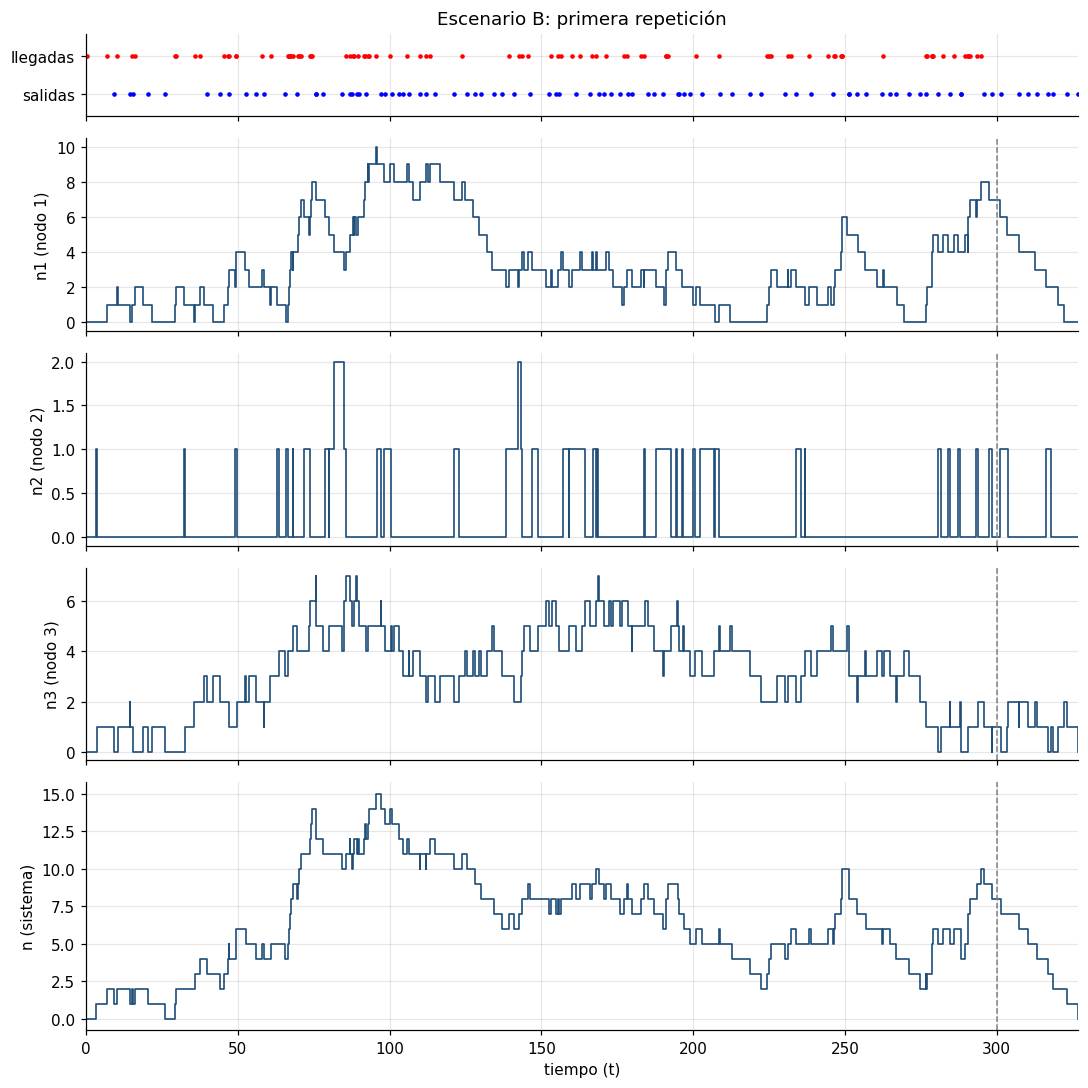

,Respuesta
Pregunta,
¿Cuál es el tiempo medio de los clientes en el sistema (t_med_sistema)?,23.2720
¿Cuál es el número promedio de clientes en el nodo 1 (n_med_n1)?,3.2319
¿Cuál es el número promedio de clientes en el nodo 2 (n_med_n2)?,0.1787
¿Cuál es el número promedio de clientes en el nodo 3 (n_med_n3)?,2.9987
¿Cuál es el tiempo transcurrido desde T hasta que el último cliente abandona el sistema?,26.7854
¿Cuál es el número máximo de clientes en el sistema?,15.0000
¿Cuál es el total de clientes que pasaron por el nodo 1 (n1)?,90.0000
¿Cuál es el total de clientes que pasaron por el nodo 2 (n2)?,36.0000
¿Cuál es el total de clientes que pasaron por el nodo 3 (n3)?,90.0000


In [8]:
esc_B = {"T": 300.0, "L": 3.0, "mu1": 3.0, "sigma1": 1.0, "mu2": 1.5,
         "mu31": 4.0, "sigma31": 2.0, "mu32": 2.0, "sigma32": 1.5}

fijar_escenario(esc_B)
np.random.seed(2025)
res_B1 = simular()
graficar("Escenario B: primera repetición", "52_escB")
responder(res_B1)


**Respuestas del escenario B (primera repetición):** el tiempo medio en el sistema fue 23,27; en promedio hubo
3,23 vehículos en N1, 0,18 en N2 y 3,00 en N3; el último vehículo salió 26,79 unidades de tiempo después de
$T$; el máximo en el sistema fue 15; pasaron 90 vehículos por N1, 36 por N2 y 90 por N3, los mismos 90 del
sistema.

El comportamiento es muy distinto al de A. N3 ya no crece sin control: pasa cerca del 80 % del tiempo con entre 2 y 6
vehículos. Ahora el nodo que manda es N1, con $\rho_1 = 3{,}0/3{,}0 = 1$, que tiene subidas y bajadas
largas propias de una cola en el límite de la estabilidad.


**Veinte repeticiones del escenario B:**

In [9]:
df_B = repetir(esc_B, 20, 2025)
df_B

,t_med_sistema,n_med_n1,n_med_n2,n_med_n3,Tp (desde T hasta la última salida),Máximo de clientes en el sistema,n1 (pasaron por N1),n2 (pasaron por N2),n3 (pasaron por N3),Total de clientes del sistema
Repetición,,,,,,,,,,
1,23.2720,3.2319,0.1787,2.9987,26.7854,15,90,36,90,90
2,24.0952,2.6019,0.3357,3.8584,39.4286,13,95,45,95,95
3,24.8776,3.1455,0.1164,3.6031,53.5511,17,98,31,98,98
4,23.8338,3.7079,0.1435,3.3526,14.2956,15,95,38,95,95
5,46.6106,9.5920,0.1697,4.1643,75.1691,27,112,48,112,112
6,23.8920,2.6820,0.2630,4.2541,16.3794,13,95,42,95,95
7,32.6376,5.6360,0.1664,3.4695,40.5809,18,97,34,97,97
8,26.0941,3.1872,0.2430,4.4148,33.1111,14,100,42,100,100
9,19.6019,2.2766,0.1626,2.8379,12.6643,12,84,36,84,84


In [10]:
tabla_B = resumen_ic(df_B)
tabla_B

,Media,Desv. estándar,IC 95 % inferior,IC 95 % superior,Semiancho,Semiancho / media (%)
t_med_sistema,31.2736,8.5904,27.2532,35.2941,4.0204,12.8557
n_med_n1,5.0342,2.4017,3.9102,6.1583,1.1240,22.3274
n_med_n2,0.1927,0.0555,0.1667,0.2187,0.0260,13.4759
n_med_n3,3.9561,0.6266,3.6628,4.2493,0.2933,7.4130
Tp (desde T hasta la última salida),41.7405,21.9625,31.4617,52.0193,10.2788,24.6254
Máximo de clientes en el sistema,18.2000,5.1463,15.7915,20.6085,2.4085,13.2337
n1 (pasaron por N1),99.6500,10.8883,94.5541,104.7459,5.0959,5.1138
n2 (pasaron por N2),39.5500,5.2763,37.0806,42.0194,2.4694,6.2437
n3 (pasaron por N3),99.6500,10.8883,94.5541,104.7459,5.0959,5.1138
Total de clientes del sistema,99.6500,10.8883,94.5541,104.7459,5.0959,5.1138


---
### Comparación de los dos escenarios

Intervalos de confianza del 95 % con la distribución $t$ de Student, $\bar{x} \pm t_{0{,}975;\,19}\, s/\sqrt{20}$,
con $t_{0{,}975;\,19} = 2{,}093$.

In [11]:
comp = pd.DataFrame({
    "A: media": tabla_A["Media"], "A: IC 95 %": [f"[{a:.3f}, {b:.3f}]" for a, b in zip(tabla_A["IC 95 % inferior"], tabla_A["IC 95 % superior"])],
    "B: media": tabla_B["Media"], "B: IC 95 %": [f"[{a:.3f}, {b:.3f}]" for a, b in zip(tabla_B["IC 95 % inferior"], tabla_B["IC 95 % superior"])],
    "¿Se traslapan?": ["sí" if not (a2 < b1 or b2 < a1) else "no"
                       for a1, a2, b1, b2 in zip(tabla_A["IC 95 % inferior"], tabla_A["IC 95 % superior"],
                                                 tabla_B["IC 95 % inferior"], tabla_B["IC 95 % superior"])]})
comp

,A: media,A: IC 95 %,B: media,B: IC 95 %,¿Se traslapan?
t_med_sistema,93.1046,"[82.357, 103.852]",31.2736,"[27.253, 35.294]",no
n_med_n1,6.3089,"[4.705, 7.913]",5.0342,"[3.910, 6.158]",sí
n_med_n2,0.4162,"[0.368, 0.465]",0.1927,"[0.167, 0.219]",no
n_med_n3,22.4450,"[20.287, 24.603]",3.9561,"[3.663, 4.249]",no
Tp (desde T hasta la última salida),184.4745,"[164.177, 204.771]",41.7405,"[31.462, 52.019]",no
Máximo de clientes en el sistema,59.6500,"[53.502, 65.798]",18.2000,"[15.791, 20.609]",no
n1 (pasaron por N1),152.0000,"[146.143, 157.857]",99.6500,"[94.554, 104.746]",no
n2 (pasaron por N2),58.5000,"[55.270, 61.730]",39.5500,"[37.081, 42.019]",no
n3 (pasaron por N3),152.0000,"[146.143, 157.857]",99.6500,"[94.554, 104.746]",no
Total de clientes del sistema,152.0000,"[146.143, 157.857]",99.6500,"[94.554, 104.746]",no


In [12]:
# intensidad de tráfico aproximada de cada nodo (llegadas al nodo / capacidad de servicio)
def rho(p):
    tasa = 1 / p["L"]
    r1 = tasa * p["mu1"]
    tasa_sale1 = min(tasa, 1 / p["mu1"])
    r2 = 0.4 * tasa_sale1 * p["mu2"]
    r3_lento, r3_rapido = tasa_sale1 * p["mu31"], tasa_sale1 * p["mu32"]
    return pd.Series({"ρ1": r1, "ρ2": r2, "ρ3 con n3 < 5": r3_lento, "ρ3 con n3 ≥ 5": r3_rapido})

pd.DataFrame({"Escenario A": rho(esc_A), "Escenario B": rho(esc_B)})

,Escenario A,Escenario B
ρ1,1.0500,1.0000
ρ2,0.4571,0.2000
ρ3 con n3 < 5,1.9524,1.3333
ρ3 con n3 ≥ 5,1.4286,0.6667


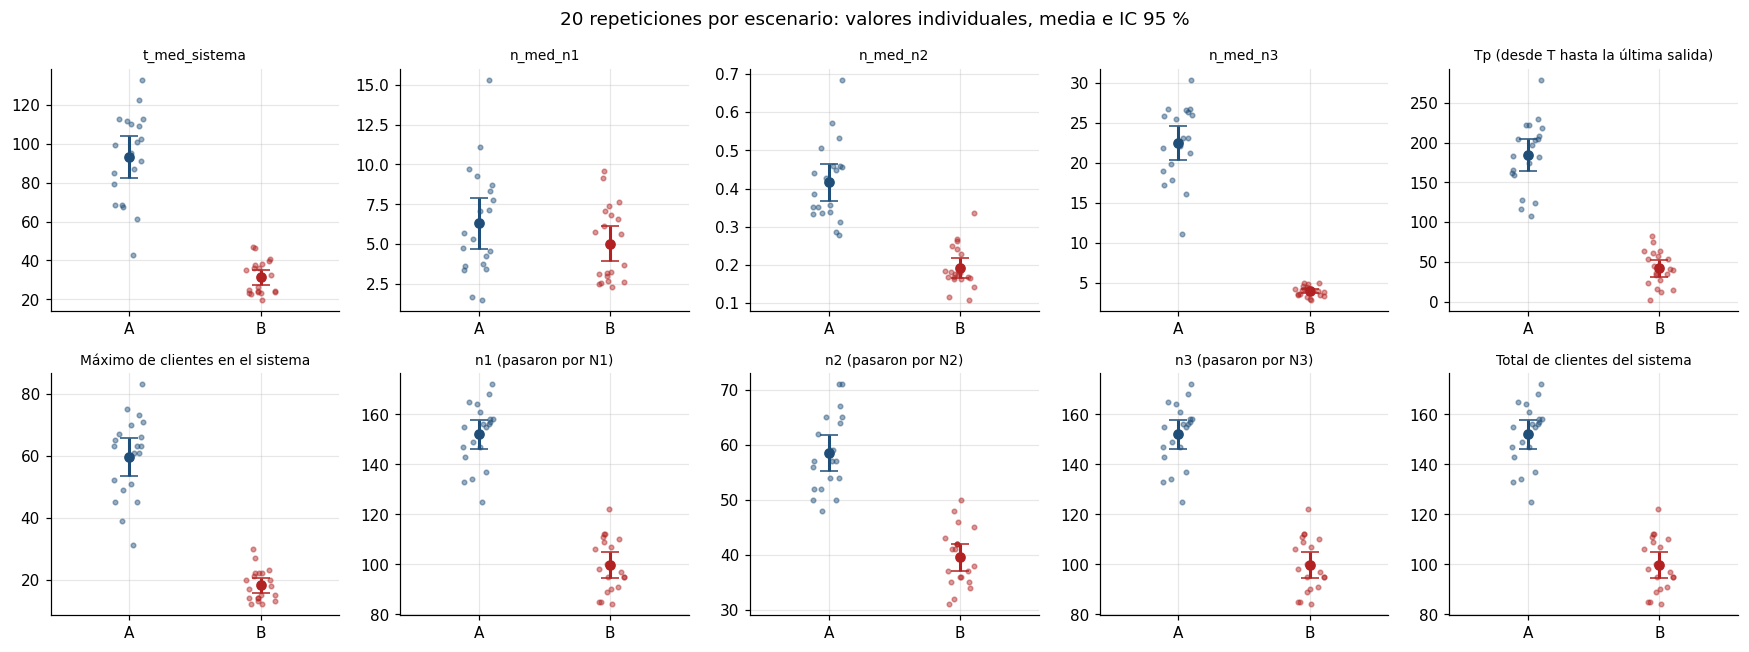

In [13]:
fig, axs = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axs.ravel(), df_A.columns):
    for k, (df, tab, color) in enumerate([(df_A, tabla_A, "#1f4e79"), (df_B, tabla_B, "#b22222")]):
        ax.plot(np.full(len(df), k) + np.random.default_rng(k).uniform(-0.12, 0.12, len(df)), df[col], ".",
                color=color, alpha=0.45)
        ax.errorbar(k, tab.loc[col, "Media"], yerr=tab.loc[col, "Semiancho"], fmt="o", color=color, capsize=6, lw=2)
    ax.set_xticks([0, 1], ["A", "B"]); ax.set_xlim(-0.6, 1.6)
    ax.set_title(col, fontsize=9)
plt.suptitle("20 repeticiones por escenario: valores individuales, media e IC 95 %")
plt.tight_layout(); guardar("52_ic"); plt.show()


### ¿Qué puede decir de la media y la desviación estándar de la muestra para cada medida de desempeño?

**Los conteos son las medidas más estables.** Por N1 pasaron $152 \pm 12{,}5$ vehículos en A y
$99{,}7 \pm 10{,}9$ en B (media $\pm$ desviación). Son justo lo que se espera de un proceso de Poisson con
$T/\lambda = 300/2 = 150$ y $300/3 = 100$ llegadas en promedio, y desviación $\sqrt{150} \approx 12{,}2$ y
$\sqrt{100} = 10$. Por N2 pasó el 38,5 % de los vehículos en A y el 39,7 % en B, muy cerca del 40 % del
modelo. Esto sirve de validación: la parte de llegadas y ruteo del simulador hace lo que debe. En los dos
escenarios $n_3$ y el total del sistema son iguales a $n_1$, porque todos los vehículos terminan en N3 y la
simulación sigue hasta que sale el último.

**Las medidas de congestión varían mucho más.** El coeficiente de variación (desviación / media) está entre 8 y 11 %
para los conteos, pero de 25 % para el tiempo en el sistema de A y de 54 % para el número medio en N1 de A
($3{,}43/6{,}31$). Estas medidas dependen de cómo se acumulan las rachas de llegadas y de servicios largos, no
solo de cuántos vehículos llegan.

**La desviación más alta relativa está siempre en N1**, que en los dos escenarios trabaja con $\rho_1 \approx 1$
(1,05 en A y 1,00 en B). Una cola en ese punto se comporta casi como una caminata aleatoria: puede pasar
mucho tiempo vacía o acumular diez vehículos según la suerte de la corrida. En la corrida 5 de A, N1 tuvo en
promedio 15,3 vehículos y en la corrida 7 solo 1,5.

**N3 muestra el efecto de la regla de los operarios.** En A, N3 tiene la media más alta (22,4 vehículos) pero
una variación relativa baja, porque siempre está saturada: ni con el ritmo rápido alcanza ($\rho_3 = 1{,}43$).
En B pasa algo interesante. Con menos de 5 vehículos N3 sería inestable ($\rho_3 = 1{,}33$), así que la cola
crece; al llegar a 5 los operarios aceleran ($\rho_3 = 0{,}67$) y la cola baja. El resultado es que N3 se
queda rondando el umbral de 5, con una media de 3,96 y la desviación más pequeña de todas (0,63). La regla
funciona como un regulador.

### ¿Qué análisis puede realizar de los intervalos de confianza identificados para cada medida de desempeño para el 95 % de confianza?

Los intervalos se calcularon con $\bar{x} \pm t_{0{,}975;\,19}\, s/\sqrt{20}$, $t_{0{,}975;\,19} = 2{,}093$. Su
lectura correcta es que, si se repitiera muchas veces el experimento completo de 20 corridas, cerca del 95 %
de los intervalos así construidos contendrían el valor esperado verdadero de la medida para un horizonte
$T = 300$. Como los dos escenarios son inestables en algún nodo, no hay un "estado estable" que estimar: lo
que se estima es el comportamiento de un periodo de 300 unidades de tiempo con arranque vacío.

**La precisión es muy desigual.** El semiancho relativo va de 3,9 % (número de vehículos en A) a 25,4 %
(número medio en N1 en A). Para el tiempo medio en el sistema de A el intervalo es $[82{,}36;\ 103{,}85]$, con
un semiancho de 10,7, el 11,5 % de la media. Si se quisiera bajar ese error al 5 % harían falta unas
$n \approx (2{,}093 \cdot 22{,}96 / (0{,}05 \cdot 93{,}10))^2 \approx 107$ corridas, cinco veces más.

**Casi todas las diferencias entre A y B son claras.** En 9 de las 10 medidas los intervalos de A y B no se
traslapan. El tiempo medio en el sistema, por ejemplo, está entre 82,4 y 103,9 en A y entre 27,3 y 35,3 en B:
el escenario B es unas tres veces mejor para el usuario, aunque en B el servicio de N1 sea más lento (3,0
contra 2,1). La mejora viene de que llegan menos vehículos y de que N3, que era el cuello de botella de A, en
B atiende más rápido cuando se congestiona ($\mu_{32} = 2{,}0$ contra 3,0).

**La única medida sin diferencia significativa es el número medio en N1**: $[4{,}70;\ 7{,}91]$ en A y
$[3{,}91;\ 6{,}16]$ en B. Tiene sentido, porque en los dos escenarios N1 está en $\rho_1 \approx 1$, y con esa
variabilidad 20 corridas no alcanzan para separar los dos casos. No quiere decir que sean iguales, sino que la
muestra no permite afirmar que sean distintos.

**Una advertencia sobre la normalidad.** El intervalo $t$ supone que la media muestral es aproximadamente
normal. Para los conteos eso se cumple bien. Para el tiempo después de $T$ o el número medio en N1, que tienen
colas largas hacia arriba (en B, el tiempo después de $T$ fue de 12,7 en una corrida y 75,2 en otra), con 20
corridas la aproximación es más dudosa y conviene tomar esos intervalos como orientativos.
